In [1]:
#| default_exp algorithms

In [2]:
#| export

import numpy as np
import matplotlib.pyplot as plt
import meshplot

In [7]:
#| export

import jax
import jax.numpy as jnp
import jax.experimental.sparse as jsparse

import functools

In [8]:
#| export

from jaxtyping import Float, Bool, Int

In [9]:
#| export

from triangulax import trigonometry as trig
from triangulax import mesh as msh
from triangulax import adjacency as adj
from triangulax import geometry as geom
from triangulax import topology as topo

In [10]:
#| hide

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
jax.config.update('jax_log_compiles', False) # use this to log JAX JIT compilations.

In [11]:
#| hide

import jaxtyping


In [12]:
#| hide

%load_ext jaxtyping 
%jaxtyping.typechecker beartype.beartype

# enables type checking. does not work for some cells (vmapping and loading/saving). For those, %unload_ext jaxtyping 


## Geometry-processing algorithms

This notebook defines geometry processing algorithms building on the geometric primitives defined in the preceding modules.


### Smoothing and remeshing

Two operations to improve mesh quality without altering surface shape:
1. Tangential smoothing moves mesh vertices to the area-weighted average of the neighbors, along the tangential direction only
2. Delaunay flips improve triangle aspect ratio by edge flips. This modifies the mesh topology, but leaves the vertex set unchanged.

In [13]:
# Load test mesh
from triangulax.triangular import TriMesh

mesh = TriMesh.read_obj("../test_meshes/disk.obj")
hemesh = msh.HeMesh.from_triangles(mesh.vertices.shape[0], mesh.faces)
vertices = mesh.vertices

  o flat_tri_ecmc


### Mesh quality assessment

Functions to evaluate triangle mesh quality: per-face maximum corner angle, summary statistics, and a human-readable quality report.

In [14]:
#| export

def get_face_angles(vertices: Float[jax.Array, "n_vertices dim"],
                        hemesh: msh.HeMesh) -> Float[jax.Array, "n_faces 3"]:
    """Get corner angle per face (radians).

    Uses the half-edge corner angles and takes the max over the three
    corners of every face.

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh connectivity.

    Returns
    -------
    Float[Array, "n_faces"]
        Maximum interior angle per triangle.
    """
    angles = geom.get_corner_angles(vertices, hemesh)
    fi = hemesh.face_incident
    face_angles = jnp.stack([angles[fi], angles[hemesh.nxt[fi]], angles[hemesh.prv[fi]]], axis=-1)
    return face_angles

In [15]:
# Test get_face_max_angles
angles = get_face_angles(vertices, hemesh)
max_angles = jnp.max(angles, axis=-1)
print(f"max angles: min={jnp.rad2deg(max_angles.min()):.1f}°,max={jnp.rad2deg(max_angles.max()):.1f}°, mean={jnp.rad2deg(max_angles.mean()):.1f}°")
assert max_angles.shape == (hemesh.n_faces,)
assert jnp.all(max_angles >= jnp.pi / 3 - 1e-6)  # max angle >= 60° always

max angles: min=60.4°,max=106.6°, mean=75.0°


In [16]:
#| export

def get_mesh_quality_stats(vertices: Float[jax.Array, "n_vertices dim"],
                           hemesh: msh.HeMesh, degenerate_angle: float = 5.0, 
                           digits: int = 5) -> dict:
    """Compute mesh quality statistics.

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh connectivity.
    degenerate_angle : float
        Threshold (degrees) for a triangle to be considered degenerate.
        (I.e. if max angle > pi-threshold or min angle < threshold.)
    digits : int
        Number of decimal digits to round the statistics to.
    Returns
    -------
    dict
        Dictionary with keys: 'areas_min', 'areas_max', 'areas_cv',
        'max_angle', 'min_angle', 'angles_std',
        'n_degenerate', 'n_total_faces'.
    """
    areas = geom.get_triangle_areas(vertices, hemesh)
    angles = get_face_angles(vertices, hemesh)
    is_degenerate = ( (jnp.rad2deg(jnp.max(angles, axis=-1)) > (180.0 - degenerate_angle))
                     | (jnp.rad2deg(jnp.min(angles, axis=-1)) < degenerate_angle) )

    return {
        'areas_min': round(float(areas.min()), digits),
        'areas_max': round(float(areas.max()), digits),
        'areas_cv': round(float(areas.std() / jnp.clip(areas.mean(), 1e-30)), digits),
        'max_angle': round(float(jnp.rad2deg(angles.max())), digits),
        'min_angle': round(float(jnp.rad2deg(angles.min())), digits),
        'angles_std': round(float(jnp.rad2deg(angles.std())), digits),
        'n_degenerate': int(is_degenerate.sum()),
        'n_total_faces': int(hemesh.n_faces),
    }

In [17]:
# Test mesh quality report
stats = get_mesh_quality_stats(vertices, hemesh)
stats

{'areas_min': 0.00615,
 'areas_max': 0.0218,
 'areas_cv': 0.18788,
 'max_angle': 106.60695,
 'min_angle': 31.15478,
 'angles_std': 13.73223,
 'n_degenerate': 0,
 'n_total_faces': 224}

### Delaunay flipping

Flip edges to improve triangle quality based on the Delaunay criterion: for each interior edge, the sum of the two opposite angles should not exceed π. Based on [GeometryCentral: Extrinsic Delaunay Flipping](https://geometry-central.net/surface/algorithms/remeshing/#extrinsic-delaunay-flipping).

Note: extrinsic flipping is *not* guaranteed to produce a fully Delaunay mesh, but generally improves quality in practice.

In [18]:
#| export

def is_locally_delaunay(vertices: Float[jax.Array, "n_vertices dim"],
                        hemesh: msh.HeMesh) -> Bool[jax.Array, " n_hes"]:
    """Check the local Delaunay condition for each edge.

    An interior edge is locally Delaunay when the sum of the two
    opposite angles does not exceed π.  Boundary edges are always
    considered Delaunay.

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh connectivity.

    Returns
    -------
    Bool[Array, "n_hes"]
        True where the edge satisfies the Delaunay condition.
    """
    angles = geom.get_corner_angles(vertices, hemesh)
    angle_sum = angles + angles[hemesh.twin]
    return hemesh.is_bdry_edge | (angle_sum <= jnp.pi + 1e-10)

In [19]:
# Test is_locally_delaunay
delaunay = is_locally_delaunay(vertices, hemesh)
print(f"Non-Delaunay edges: {(~delaunay & hemesh.is_unique & ~hemesh.is_bdry_edge).sum()}")
assert delaunay.shape == (hemesh.n_hes,)
assert jnp.all(delaunay[hemesh.is_bdry_edge])  # boundary edges are always Delaunay

Non-Delaunay edges: 4


In [20]:
#| export

@functools.partial(jax.jit, static_argnames=['max_iters'])
def fix_delaunay(vertices: Float[jax.Array, "n_vertices dim"],
                 hemesh: msh.HeMesh,
                 max_iters: int = 2) -> tuple[msh.HeMesh, Int[jax.Array, ""]]:
    """Flip non-Delaunay edges iteratively until convergence.

    Each iteration identifies non-Delaunay interior edges and flips them
    using ``topology.flip_all``.  Stops when no more flips are needed
    or ``max_iters`` is reached.

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions (unchanged by flips).
    hemesh : HeMesh
        Half-edge mesh connectivity.
    max_iters : int
        Maximum number of sweep iterations.

    Returns
    -------
    hemesh_new : HeMesh
        Updated half-edge mesh with improved Delaunay quality.
    n_flips : int
        Total number of edges flipped.
    """
    def cond_fun(state):
        hemesh_s, n_flips, i, did_flip = state
        return (i < max_iters) & did_flip

    def body_fun(state):
        hemesh_s, n_flips, i, _ = state
        delaunay = is_locally_delaunay(vertices, hemesh_s)
        to_flip = ~delaunay & hemesh_s.is_unique & ~hemesh_s.is_bdry_edge
        n_new = to_flip.sum()
        hemesh_s = topo.flip_all(hemesh_s, to_flip)
        return (hemesh_s, n_flips + n_new, i + 1, n_new > 0)

    init_state = (hemesh, jnp.array(0), jnp.array(0), jnp.array(True))
    hemesh_out, n_flips, _, _ = jax.lax.while_loop(cond_fun, body_fun, init_state)
    return hemesh_out, n_flips

In [21]:
#| notest
# Test fix_delaunay: perturb vertices to create non-Delaunay edges, then fix
key = jax.random.PRNGKey(42)
noise = 0.025 * jax.random.normal(key, shape=vertices.shape)
noisy_vertices = vertices + noise

n_bad_before = (~is_locally_delaunay(noisy_vertices, hemesh) & hemesh.is_unique & ~hemesh.is_bdry_edge).sum()
print(f"Non-Delaunay edges before: {n_bad_before}")

hemesh_fixed, n_flips = fix_delaunay(noisy_vertices, hemesh, max_iters=1)
n_bad_after = (~is_locally_delaunay(noisy_vertices, hemesh_fixed) & hemesh_fixed.is_unique & ~hemesh_fixed.is_bdry_edge).sum()
print(f"Flips performed: {n_flips}")
print(f"Non-Delaunay edges after:  {n_bad_after}")

print("\nBefore fix_delaunay:")
print(get_mesh_quality_stats(noisy_vertices, hemesh))
print("\nAfter fix_delaunay:")
print(get_mesh_quality_stats(noisy_vertices, hemesh_fixed))

Non-Delaunay edges before: 15
Flips performed: 15
Non-Delaunay edges after:  0

Before fix_delaunay:
{'areas_min': 0.00301, 'areas_max': 0.02994, 'areas_cv': 0.32373, 'max_angle': 126.89138, 'min_angle': 9.82493, 'angles_std': 18.8009, 'n_degenerate': 0, 'n_total_faces': 224}

After fix_delaunay:
{'areas_min': 0.00301, 'areas_max': 0.03013, 'areas_cv': 0.32043, 'max_angle': 120.57028, 'min_angle': 9.82493, 'angles_std': 17.33338, 'n_degenerate': 0, 'n_total_faces': 224}


(np.float64(-1.0870901427296413),
 np.float64(1.097853572442067),
 np.float64(-1.1177076607221643),
 np.float64(1.1221007508660394))

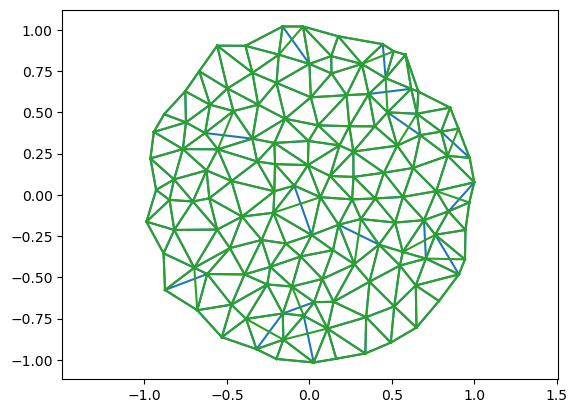

In [22]:
plt.triplot(noisy_vertices[:, 0], noisy_vertices[:, 1], hemesh.faces)
plt.triplot(noisy_vertices[:, 0], noisy_vertices[:, 1], hemesh_fixed.faces)
plt.axis('equal')

### Tangential vertex smoothing

Vertex smoothing moves each vertex towards the average of its neighborhood. `triangulax` implements **laplacian smoothing**, which moves vertices towards the average of neighboring vertex positions.

In either case, for 3D meshes the displacement is projected tangentially (normal component removed). Boundary conditions can be `'fixed'` (boundary vertices immobile) or `'free'`.

Based on: [GeometryCentral: Tangential Vertex Smoothing](https://geometry-central.net/surface/algorithms/remeshing/#tangential-vertex-smoothing).

In [ ]:
#| export

def smooth_vertices_laplacian(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh,
                              step_size: float = 1.0, bc: str = 'fixed') -> Float[jax.Array, "n_vertices dim"]:
    """One step of tangential Laplacian vertex smoothing.

    Moves each vertex towards the mean position of its neighbours.
    For 3D meshes, the displacement is projected onto the tangent plane.

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh connectivity.
    step_size : float
        Fraction of displacement to apply (1 = full step).
    bc : str
        Boundary condition: 'fixed' freezes boundary vertices,
        'free' allows them to move, and 'slide' allows them to
        move only tangentially along the boundary.

    Returns
    -------
    Float[Array, "n_vertices dim"]
        Updated vertex positions.
    """
    triangle_areas = geom.get_triangle_areas(vertices, hemesh)
    weights = triangle_areas[hemesh.heface] + triangle_areas[hemesh.heface[hemesh.twin]]
    normalization = adj.sum_he_to_vertex_incoming(hemesh, weights)
    average_neighbor = adj.sum_he_to_vertex_incoming(hemesh, weights[:, None] * vertices[hemesh.orig])
    average_neighbor = average_neighbor/ normalization[:, None]

    step = step_size * (average_neighbor - vertices)

    if vertices.shape[1] == 3:
        normals = geom.get_vertex_normals(vertices, hemesh)
        step = jax.vmap(trig.project_out_vector)(step, normals)

    if bc == 'fixed':
        step = jnp.where(hemesh.is_bdry[:, None], 0.0, step)

    

    return vertices + step

In [34]:
# Test Laplacian smoothing on a noisy 2D mesh

key = jax.random.PRNGKey(0)
noise = 0.05 * jax.random.normal(key, shape=vertices.shape)
noisy_v = vertices + jnp.where(hemesh.is_bdry[:, None], 0.0, noise)

print("Before smoothing:")
print(get_mesh_quality_stats(noisy_v, hemesh))

smoothed_v = noisy_v
for _ in range(10):
    smoothed_v = smooth_vertices_laplacian(smoothed_v, hemesh, step_size=0.5, bc='fixed')

print("\nAfter 10 Laplacian smoothing steps:")
print(get_mesh_quality_stats(smoothed_v, hemesh))

# Boundary vertices should not have moved
assert jnp.allclose(smoothed_v[hemesh.is_bdry], noisy_v[hemesh.is_bdry])

Before smoothing:
{'areas_min': 0.00012, 'areas_max': 0.04031, 'areas_cv': 0.56271, 'max_angle': 178.81132, 'min_angle': 0.47529, 'angles_std': 30.37956, 'n_degenerate': 4, 'n_total_faces': 224}

After 10 Laplacian smoothing steps:
{'areas_min': 0.00826, 'areas_max': 0.01995, 'areas_cv': 0.14647, 'max_angle': 105.55561, 'min_angle': 28.34853, 'angles_std': 9.80379, 'n_degenerate': 0, 'n_total_faces': 224}


(np.float64(-1.10003475),
 np.float64(1.09628575),
 np.float64(-1.09934025),
 np.float64(1.09050125))

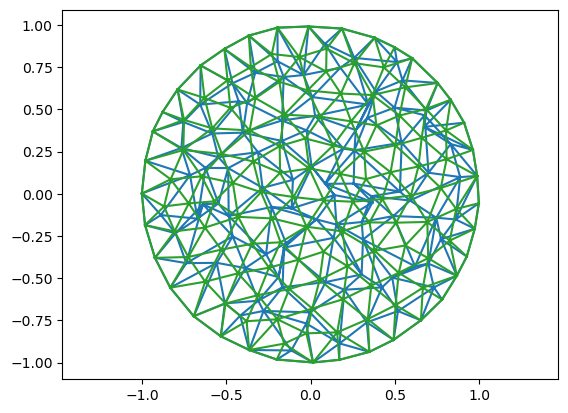

In [25]:
plt.triplot(noisy_v[:, 0], noisy_v[:, 1], hemesh.faces)
plt.triplot(smoothed_v[:, 0], smoothed_v[:, 1], hemesh.faces)
plt.axis('equal')

In [32]:
#| notest
# Test 3D tangential smoothing on a sphere
mesh_3d = TriMesh.read_obj("../test_meshes/sphere.obj", dim=3)
hemesh_3d = msh.HeMesh.from_triangles(mesh_3d.vertices.shape[0], mesh_3d.faces)
verts_3d = mesh_3d.vertices

key = jax.random.PRNGKey(1)
noise_3d = 0.1 * jax.random.normal(key, shape=verts_3d.shape)
noisy_3d = verts_3d + noise_3d

print("Before 3D smoothing:")
print(get_mesh_quality_stats(noisy_3d, hemesh_3d))

smoothed_3d = noisy_3d
for _ in range(5):
    smoothed_3d = smooth_vertices_laplacian(smoothed_3d, hemesh_3d, step_size=0.3, bc='free')

print("\nAfter 5 Laplacian smoothing steps (3D):")
print(get_mesh_quality_stats(smoothed_3d, hemesh_3d))

Before 3D smoothing:
{'areas_min': 0.05567, 'areas_max': 0.31956, 'areas_cv': 0.35048, 'max_angle': 120.09799, 'min_angle': 19.84483, 'angles_std': 17.23441, 'n_degenerate': 0, 'n_total_faces': 80}

After 5 Laplacian smoothing steps (3D):
{'areas_min': 0.10323, 'areas_max': 0.20764, 'areas_cv': 0.13673, 'max_angle': 79.5562, 'min_angle': 45.60472, 'angles_std': 7.12533, 'n_degenerate': 0, 'n_total_faces': 80}


  o Icosphere


In [33]:
p = meshplot.plot(noisy_3d, hemesh_3d.faces, shading={"wireframe":True}, return_plot=True)

p.add_mesh(smoothed_3d + np.array([3, 0, 0]), hemesh_3d.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.023059…

1